# 10 - Final results: table, chart and Excel report
**Run last**, after notebooks 06-09. Re-scores the saved ML models, merges with the DL / LightGBM rows already stored,
then writes `outputs/leakfree_results.csv`, `leakfree_accuracy_chart.png`, `final_results.xlsx`, `final_results_table.png`.
Needs `pip install matplotlib openpyxl`.

In [1]:
import sys, os
from pathlib import Path
# works whether Jupyter starts in the project root or inside notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT))      # lets us import data_utils.py from the root
print("Project root:", ROOT)

Project root: c:\Users\aru12\OneDrive\Desktop\capstone project


## 1. Imports and data

In [2]:
import joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from data_utils import *
(_, _), (Xva, yva), (Xte, yte) = load_splits()

## 2. Re-score the four saved ML models (threshold from validation, scores on test)

In [3]:
rows = []
for name in ["LogisticRegression", "RandomForest", "HistGradientBoosting", "XGBoost"]:
    pipe = joblib.load(ROOT / f"models/{name}.joblib")
    t = best_threshold(yva, pipe.predict_proba(Xva)[:, 1])
    rows.append(metrics_row(name, yte, pipe.predict_proba(Xte)[:, 1], t))
tbl = save_rows(rows)            # merges with LightGBM / MLP / Wide&Deep rows saved by notebooks 07-09
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 20)
tbl.drop(columns=["Features", "Train/Val/Test"])

,Model,Test_rows,Threshold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,LightGBM,236927,0.55,0.8302,0.8301,0.5353,0.8299,0.6508,0.9114
1,MLP (embeddings),236927,0.57,0.8327,0.8336,0.5397,0.8350,0.6556,0.9136
2,Wide&Deep (DL),236927,0.58,0.8332,0.8320,0.5408,0.8301,0.6549,0.9127
3,LogisticRegression,236927,0.53,0.8271,0.8276,0.5299,0.8285,0.6463,0.9094
4,RandomForest,236927,0.51,0.8304,0.8301,0.5357,0.8295,0.6510,0.9104
5,HistGradientBoosting,236927,0.55,0.8296,0.8299,0.5342,0.8303,0.6501,0.9113
6,XGBoost,236927,0.52,0.8312,0.8311,0.5371,0.8309,0.6524,0.9125


## 3. Accuracy vs balanced accuracy chart

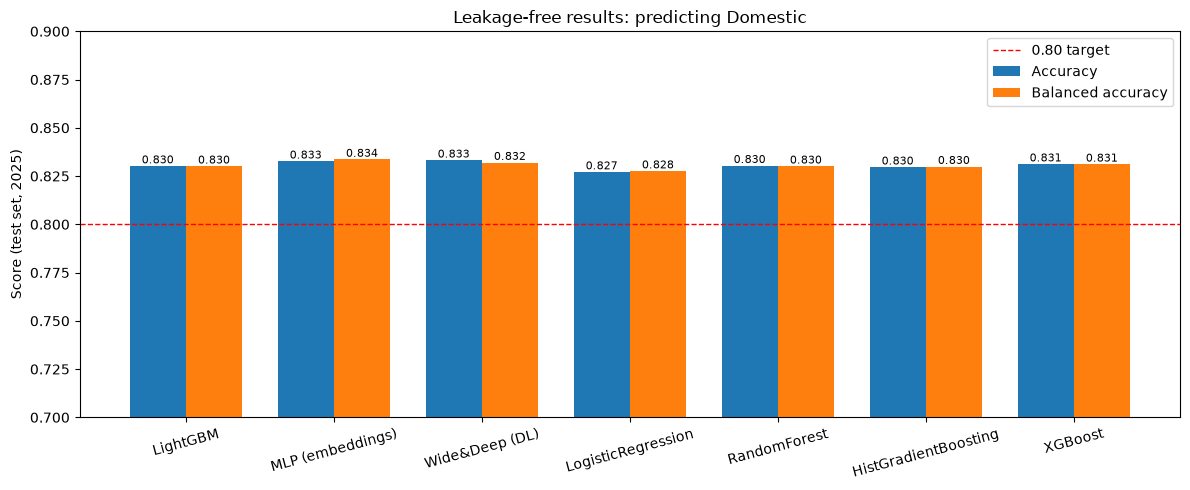

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(tbl)); w = 0.38
b1 = ax.bar(x - w/2, tbl.Accuracy, w, label="Accuracy")
b2 = ax.bar(x + w/2, tbl.Balanced_Accuracy, w, label="Balanced accuracy")
ax.bar_label(b1, fmt="%.3f", fontsize=8); ax.bar_label(b2, fmt="%.3f", fontsize=8)
ax.axhline(0.8, color="red", ls="--", lw=1, label="0.80 target")
ax.set_xticks(x); ax.set_xticklabels(tbl.Model, rotation=15); ax.set_ylim(0.7, 0.9)
ax.set_ylabel("Score (test set, 2025)"); ax.set_title("Leakage-free results: predicting Domestic")
ax.legend(); plt.tight_layout()
plt.savefig(OUT_DIR / "leakfree_accuracy_chart.png", dpi=150)
plt.show()

## 4. Ranked results table + Excel report

In [6]:
%pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.


In [7]:
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

df = pd.read_csv(RESULTS)
df["Type"] = np.where(df.Model.str.contains("MLP|Wide"), "Deep Learning", "Machine Learning")
df = df.sort_values(["Balanced_Accuracy", "Accuracy"], ascending=False).reset_index(drop=True)
df.insert(0, "Rank", df.index + 1)
df["Gap"] = (df.Accuracy - df.Balanced_Accuracy).abs().round(4)
cols = ["Rank", "Model", "Type", "Accuracy", "Balanced_Accuracy", "Gap",
        "Precision", "Recall", "F1", "ROC_AUC", "Threshold", "Test_rows"]
final = df[cols]

notes = pd.DataFrame({"Item": ["Target", "Features used", "Train period", "Validation period", "Test period",
                               "Threshold", "Leakage safeguards", "", "", "", ""],
    "Detail": ["Domestic (crime is domestic-related: yes/no)", " + ".join(FEATURES),
               "Jan 2023 - Jun 2024", "Jul 2024 - Dec 2024 (threshold, early stopping, feature selection)",
               "2025 (scored once, never used for any decision)",
               "Chosen on validation to maximise min(accuracy, balanced accuracy)",
               "Chronological split (no random shuffling)",
               "Year, Description, IUCR, FBI Code, Block, IDs excluded",
               "Encoders / vocabularies fitted on train data only",
               "Class weights for imbalance (no resampling of test data)",
               "Shuffled-label check ~0.5 AUC (no leakage)"]})
xlsx = OUT_DIR / "final_results.xlsx"
with pd.ExcelWriter(xlsx, engine="openpyxl") as w_:
    final.to_excel(w_, sheet_name="Results", index=False)
    notes.to_excel(w_, sheet_name="Method", index=False)
wb = load_workbook(xlsx)
head = PatternFill("solid", fgColor="1F4E78"); good = PatternFill("solid", fgColor="C6EFCE")
best_fill = PatternFill("solid", fgColor="FFE699"); thin = Side(style="thin", color="BBBBBB")
for ws in wb:
    for c in ws[1]:
        c.font = Font(bold=True, color="FFFFFF"); c.fill = head
        c.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    for col in ws.columns:
        ws.column_dimensions[get_column_letter(col[0].column)].width = \
            min(70, max(len(str(c.value)) for c in col if c.value is not None) + 3)
    for row in ws.iter_rows(min_row=2):
        for c in row: c.border = Border(top=thin, bottom=thin, left=thin, right=thin)
ws = wb["Results"]
ai, bi = cols.index("Accuracy") + 1, cols.index("Balanced_Accuracy") + 1
for r in range(2, ws.max_row + 1):
    for ci in (ai, bi):
        c = ws.cell(r, ci); c.number_format = "0.0000"
        if c.value >= 0.8: c.fill = good                  # green = meets the 0.80 target
    if r == 2:
        for c in ws[r]: c.font = Font(bold=True)
        ws.cell(r, 2).fill = best_fill                    # best model highlighted
    for ci in range(cols.index("Precision") + 1, cols.index("ROC_AUC") + 2):
        ws.cell(r, ci).number_format = "0.0000"
ws.freeze_panes = "A2"
wb.save(xlsx)
print("Saved:", xlsx)
final

Saved: c:\Users\aru12\OneDrive\Desktop\capstone project\outputs\final_results.xlsx


,Rank,Model,Type,Accuracy,Balanced_Accuracy,Gap,Precision,Recall,F1,ROC_AUC,Threshold,Test_rows
0,1,MLP (embeddings),Deep Learning,0.8327,0.8336,0.0009,0.5397,0.8350,0.6556,0.9136,0.57,236927
1,2,Wide&Deep (DL),Deep Learning,0.8332,0.8320,0.0012,0.5408,0.8301,0.6549,0.9127,0.58,236927
2,3,XGBoost,Machine Learning,0.8312,0.8311,0.0001,0.5371,0.8309,0.6524,0.9125,0.52,236927
3,4,RandomForest,Machine Learning,0.8304,0.8301,0.0003,0.5357,0.8295,0.6510,0.9104,0.51,236927
4,5,LightGBM,Machine Learning,0.8302,0.8301,0.0001,0.5353,0.8299,0.6508,0.9114,0.55,236927
5,6,HistGradientBoosting,Machine Learning,0.8296,0.8299,0.0003,0.5342,0.8303,0.6501,0.9113,0.55,236927
6,7,LogisticRegression,Machine Learning,0.8271,0.8276,0.0005,0.5299,0.8285,0.6463,0.9094,0.53,236927


## 5. Table image for your report / slides

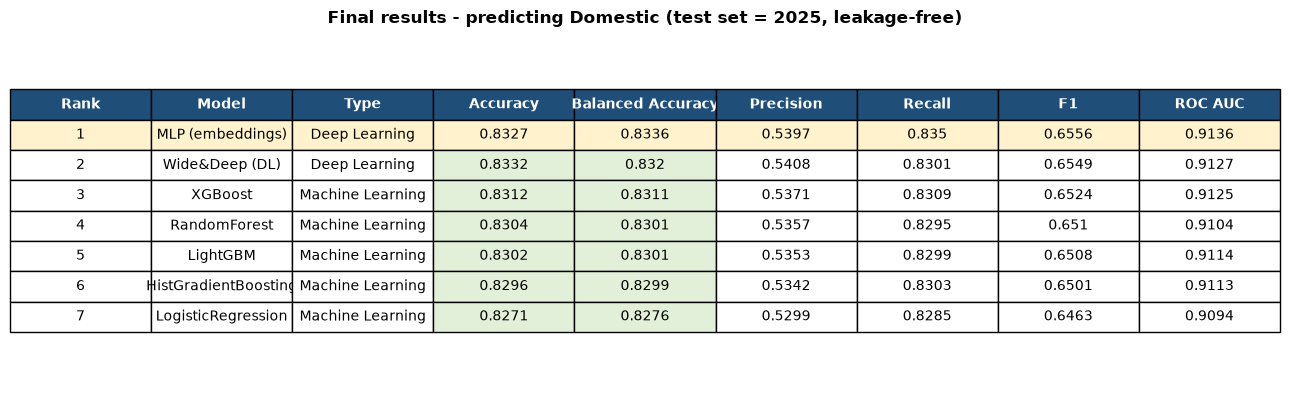

In [8]:
show = final[["Rank", "Model", "Type", "Accuracy", "Balanced_Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]]
fig, ax = plt.subplots(figsize=(13, 0.6 + 0.5 * len(show))); ax.axis("off")
t_ = ax.table(cellText=show.round(4).astype(str).values, colLabels=[c.replace("_", " ") for c in show.columns],
              loc="center", cellLoc="center")
t_.auto_set_font_size(False); t_.set_fontsize(10); t_.scale(1, 1.6)
for (r, c), cell in t_.get_celld().items():
    if r == 0: cell.set_facecolor("#1F4E78"); cell.set_text_props(color="white", weight="bold")
    elif r == 1: cell.set_facecolor("#FFF2CC")
    elif c in (3, 4) and float(show.iloc[r - 1, c]) >= 0.8: cell.set_facecolor("#E2F0D9")
ax.set_title("Final results - predicting Domestic (test set = 2025, leakage-free)", fontweight="bold")
plt.tight_layout(); plt.savefig(OUT_DIR / "final_results_table.png", dpi=170, bbox_inches="tight")
plt.show()